## **Parte II**

- feature enginnering;
- modelagem;
- Avaliação do modelo.

In [58]:
# ===============================
#   IMPORTAÇÃO DAS BIBLIOTECAS
# ===============================

import pandas as pd
import joblib
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

from sklearn.preprocessing import KBinsDiscretizer

In [ ]:
# ===========================
#   CARREGANDO AS BASES
# ===========================
X_train, X_test, y_train, y_test = joblib.load('../bases/processada/dados_modelagem.pkl')

In [60]:
# ==================================================================
#   FEATURES ENGINNERING E CODIFICAÇÃO DAS VARIÁVEIS CATEGÓRICAS
# ==================================================================
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# tranformando categórica estado civil e nível educacional em numérica
# Padronizando 'Alone', 'Absurd' e 'Yolo' como 'Single'
X_train['estado_civil'] = X_train['estado_civil'].replace({
    'Alone': 'Single',
    'Absurd': 'Single',
    'YOLO': 'Single'
})

X_test['estado_civil'] = X_test['estado_civil'].replace({
    'Alone': 'Single',
    'Absurd': 'Single',
    'YOLO': 'Single'
})

# dummificando colunas categóricas
X_train = pd.get_dummies(
    X_train,
    columns=['nivel_educacional', 'estado_civil'], 
    drop_first=True,
    dtype=int
)

# dummificando colunas categóricas do teste
X_test = pd.get_dummies(
    X_test,
    columns=['nivel_educacional', 'estado_civil'], 
    drop_first=True,
    dtype=int
)

# Transformando ano de nascimento em idade
X_train['idade'] = (2025 - X_train['ano_nascimento']).astype(int)
X_test['idade'] = (2025 - X_test['ano_nascimento']).astype(int)

# criando gasto_total, somando gastos.
X_train['gasto_total'] = (
    X_train['total_vinhos'] +
    X_train['total_frutas'] +
    X_train['total_carnes'] +
    X_train['total_peixes'] +
    X_train['total_doces'] +
    X_train['total_ouro']
)

X_test['gasto_total'] = (
    X_test['total_vinhos'] +
    X_test['total_frutas'] +
    X_test['total_carnes'] +
    X_test['total_peixes'] +
    X_test['total_doces'] +
    X_test['total_ouro']
)


# criando scores RFM
# --- RECÊNCIA (R) ---
# Instancia, treina e transforma
discretizer_R = KBinsDiscretizer(n_bins=4, encode="ordinal", strategy="quantile")
X_train["score_R"] = discretizer_R.fit_transform(X_train[["recencia"]])
X_test["score_R"] = discretizer_R.transform(X_test[["recencia"]])

# Inverte a ordem dos labels (Menor recência = Cliente mais recente = Nota maior)
X_train["score_R"] = 4 - X_train["score_R"]
X_test["score_R"] = 4 - X_test["score_R"]


# --- FREQUÊNCIA (F) ---
discretizer_F = KBinsDiscretizer(n_bins=4, encode="ordinal", strategy="quantile")
X_train["score_F"] = discretizer_F.fit_transform(X_train[["frequencia_loja"]])
X_test["score_F"] = discretizer_F.transform(X_test[["frequencia_loja"]])

# Ajusta para escala 1 a 3
X_train["score_F"] = X_train["score_F"]
X_test["score_F"] = X_test["score_F"]


# --- MONETÁRIO (M) ---
discretizer_M = KBinsDiscretizer(n_bins=4, encode="ordinal", strategy="quantile")
X_train["score_M"] = discretizer_M.fit_transform(X_train[["gasto_total"]])
X_test["score_M"] = discretizer_M.transform(X_test[["gasto_total"]])

# Ajusta para escala 1 a 3
X_train["score_M"] = X_train["score_M"]
X_test["score_M"] = X_test["score_M"]

# criando flag de renda alta e sem filhos
X_train['alta_renda_sem_filhos'] = ((X_train['score_R'] >= 2) & (X_train['qtd_criancas'] == 0)).astype(int)
X_test['alta_renda_sem_filhos'] = ((X_test['score_R'] >= 2) & (X_test['qtd_criancas'] == 0)).astype(int)

In [61]:
# =====================================================
#   EXCLUSÃO DE COLUNAS PÓS ENGENHARIA DE ATRIBUTOS
# =====================================================

# excluindo  'ano_nascimento' pois foi transformada
X_train = X_train.drop(columns= 'ano_nascimento')
X_test = X_test.drop(columns= 'ano_nascimento')

In [62]:
# ====================================
# ALINHAMENTO DE COLUNAS DAS BASES
# ====================================

X_test.reindex(columns=X_train.columns, fill_value=0)
print('Alinhamento ok! Estrutura da base de treino:\n')
print(f' {X_train.shape[0]} linhas | {X_train.shape[1]} colunas')

Alinhamento ok! Estrutura da base de treino:

 1528 linhas | 26 colunas


In [63]:
# ====================================
#   TREINAMENTO DO PRIMEIRO MODELO
# ====================================
# instanciando o baseline
model = DecisionTreeClassifier(max_depth=7, criterion='gini', random_state=42)

# treinamento com validação cruzada
# configurando
cv = KFold(
    n_splits=5,     # número de dobras
    shuffle=True,       # embaralhamento dos dados
    random_state=42         # reprodutibilidade
)

scores1 = cross_val_score(
    model,
    X_train,
    y_train,
    cv=cv,
    scoring='roc_auc'
)

print(f'Resultado em cada fold: \n {scores1}')
print(f'Roc_Auc média: {scores1.mean().round(2)}')
print(f'Desvio padrão: {scores1.std().round(4)}')

Resultado em cada fold: 
 [0.86775959 0.92523504 0.9075142  0.91044032 0.91702503]
Roc_Auc média: 0.91
Desvio padrão: 0.0199


In [64]:
# =========================================
#   TREINAMENTO FINAL DO PRIMEIRO MODELO
# =========================================
model.fit(X_train, y_train)

y_prev1 = model.predict(X_train)
y_proba1 = model.predict_proba(X_train)[:, 1]

print(f'Roc_Auc: {roc_auc_score(y_train, y_proba1):.2f}')
print(f'Relatório de classificação: \n {classification_report(y_train, y_prev1)}')

Roc_Auc: 0.98
Relatório de classificação: 
               precision    recall  f1-score   support

           0       0.99      0.91      0.95       750
           1       0.92      0.99      0.96       778

    accuracy                           0.95      1528
   macro avg       0.96      0.95      0.95      1528
weighted avg       0.96      0.95      0.95      1528



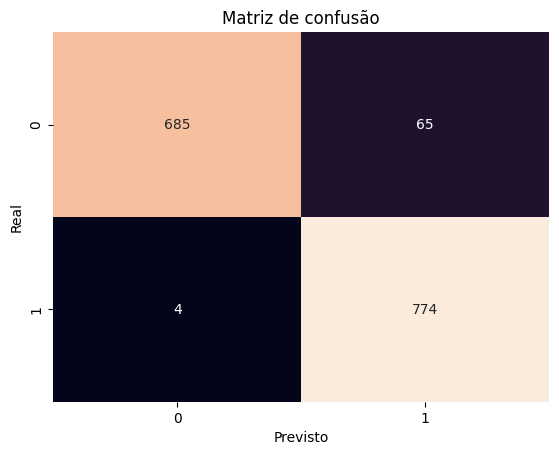

In [65]:
sns.heatmap(
    confusion_matrix(y_train, y_prev1),
    cbar=False,
    annot=True,
    fmt='d'
)

plt.ylabel('Real')
plt.xlabel("Previsto")
plt.title('Matriz de confusão')

plt.show()


In [66]:
# =======================================
#   TREINAMENTO DO MODELO RANDOM FOREST
# =======================================
# instanciando o modelo, com 200 árvores de decisão, método gini de limpeza e profundidade 5
model_rf = RandomForestClassifier(n_estimators= 200, criterion= 'gini', max_depth=5)

# treinamento com validação cruzada
scores2 = cross_val_score(
    model_rf,
    X_train,
    y_train,
    cv=cv,
    scoring='roc_auc'
)

print(f'Resultado em cada fold: \n {scores2}')
print(f'Roc_Auc média: {scores2.mean().round(2)}')
print(f'Desvio padrão: {scores2.std().round(4)}')

Resultado em cada fold: 
 [0.94767666 0.95384615 0.95510274 0.92740747 0.9461168 ]
Roc_Auc média: 0.95
Desvio padrão: 0.0099


In [67]:
# =========================================
#   TREINAMENTO FINAL DO SEGUNDO MODELO
# =========================================
model_rf.fit(X_train, y_train)

y_prev2 = model_rf.predict(X_train)
y_proba2 = model_rf.predict_proba(X_train)[:, 1]

print(f'Roc_Auc: {roc_auc_score(y_train, y_proba2):.2f}')
print(f'Relatório de classificação: \n {classification_report(y_train, y_prev2)}')

Roc_Auc: 0.98
Relatório de classificação: 
               precision    recall  f1-score   support

           0       0.98      0.83      0.89       750
           1       0.85      0.98      0.91       778

    accuracy                           0.90      1528
   macro avg       0.91      0.90      0.90      1528
weighted avg       0.91      0.90      0.90      1528



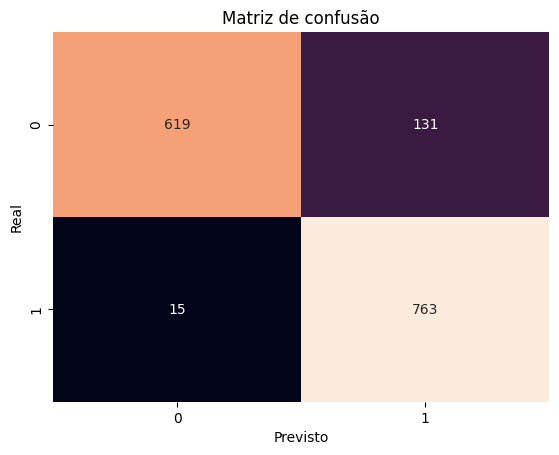

In [68]:
sns.heatmap(
    confusion_matrix(y_train, y_prev2),
    cbar=False,
    annot=True,
    fmt='d'
)

plt.ylabel('Real')
plt.xlabel("Previsto")
plt.title('Matriz de confusão')

plt.show()

In [69]:
# =======================================
#   TREINAMENTO DO MODELO XGBOOST
# =======================================
from xgboost import XGBRFClassifier
import xgboost as xgb


# instanciando o modelo, com 200 árvores de decisão, método gini de limpeza e profundidade 5
model_xgb = XGBRFClassifier(
    n_estimators= 300,
    learning_rate=0.03,
    random_state=42
)

# treinamento com validação cruzada
scores3 = cross_val_score(
    model_xgb,
    X_train,
    y_train,
    cv=cv,
    scoring='roc_auc'
)

print(f'Resultado em cada fold: \n {scores3}')
print(f'Roc_Auc média: {scores3.mean().round(2)}')
print(f'Desvio padrão: {scores3.std().round(4)}')

Resultado em cada fold: 
 [0.96139871 0.96547009 0.96432996 0.94890353 0.96318913]
Roc_Auc média: 0.96
Desvio padrão: 0.006


In [70]:
# =========================================
#   TREINAMENTO FINAL DO TERCEIRO MODELO
# =========================================
model_xgb.fit(X_train, y_train)

y_prev3 = model_xgb.predict(X_train)
y_proba3 = model_xgb.predict_proba(X_train)[:, 1]

print(f'Roc_Auc: {roc_auc_score(y_train, y_proba3):.2f}')
print(f'Relatório de classificação: \n {classification_report(y_train, y_prev3)}')

Roc_Auc: 0.99
Relatório de classificação: 
               precision    recall  f1-score   support

           0       1.00      0.81      0.90       750
           1       0.85      1.00      0.92       778

    accuracy                           0.91      1528
   macro avg       0.92      0.91      0.91      1528
weighted avg       0.92      0.91      0.91      1528



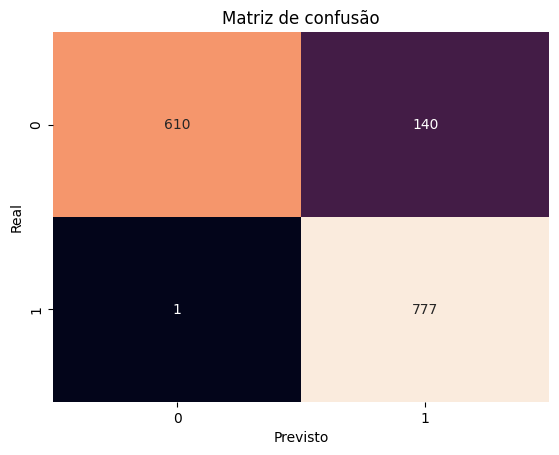

In [71]:
# matriz de confusão
sns.heatmap(
    confusion_matrix(y_train, y_prev3),
    cbar=False,
    annot=True,
    fmt='d'
)

plt.ylabel('Real')
plt.xlabel("Previsto")
plt.title('Matriz de confusão')

plt.show()

,modelo,roc_auc,precision,desvio_padrão,acurácia
0,Árvore de decisão,0.98,0.92,0.02,0.95
1,Random Forest,0.98,0.85,0.01,0.90
2,Xgboost,0.99,0.85,0.01,0.91


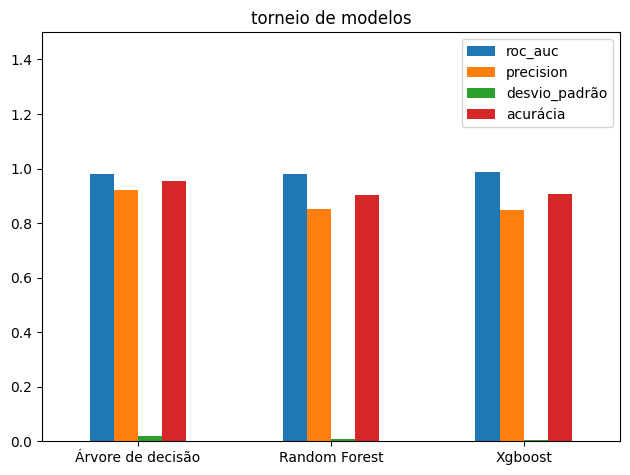

In [72]:
# ============================
#   TORNEIO DE MODELOS
#=============================

# relatório de classificação do baseline
relatorio_baseline = pd.DataFrame(classification_report(y_train, y_prev1, output_dict=True))

# métricas baseline
roc_auc_baseline = roc_auc_score(y_train, y_proba1)
precision_baseline = relatorio_baseline.loc['precision', '1']
std_baseline = scores1.std()
acuracia = relatorio_baseline.loc['precision', 'accuracy']

# relatório de classificação do random forest
relatorio_rf = pd.DataFrame(classification_report(y_train, y_prev2, output_dict=True))

# métricas random forest
roc_auc_rf = roc_auc_score(y_train, y_proba2)
precision_rf = relatorio_rf.loc['precision', '1']
std_rf = scores2.std()
acuracia_rf = relatorio_rf.loc['precision', 'accuracy']

# relatório de classificação do random forest
relatorio_xgb = pd.DataFrame(classification_report(y_train, y_prev3, output_dict=True))

# métricas random forest
roc_auc_xgb = roc_auc_score(y_train, y_proba3)
precision_xgb = relatorio_xgb.loc['precision', '1']
std_xgb = scores3.std()
acuracia_xgb = relatorio_xgb.loc['precision', 'accuracy']

# criando um dataframe com os resultados
metricas_torneio = {
    'modelo': ['Árvore de decisão', 'Random Forest', 'Xgboost'],
    'roc_auc': [roc_auc_baseline, roc_auc_rf, roc_auc_xgb],
    'precision': [precision_baseline, precision_rf, precision_xgb],
    'desvio_padrão': [std_baseline, std_rf, std_xgb],
    'acurácia': [acuracia, acuracia_rf, acuracia_xgb]
}

metricas_duelo = pd.DataFrame(metricas_torneio)
display(metricas_duelo.round(2))
metricas_duelo.plot(kind='bar')

plt.title('torneio de modelos')
plt.tight_layout()
plt.xticks([0, 1, 2], ['Árvore de decisão', 'Random Forest', 'Xgboost'])
plt.ylim(0, 1.5)
plt.xticks(rotation=0)

plt.show()

In [73]:
# ===========================================
#   Busca pelos melhores hiperparâmetros
# ===========================================
from sklearn.model_selection import RandomizedSearchCV

# instanciando um modelo do zero
algoritmo_xgb = XGBRFClassifier()

# dicionário de hiperparâmetros
param_grid = {
    'n_estimators': [200, 300, 400],
    'learning_rate': [0.001, 0.1, 0.3, 0.5, 1],
    'max_depth': [3, 4, 5, 6, 7],
    'min_child_weight': [2, 4, 6, 8, 10],
    'reg_lambda': [0.1, 1.0, 10.0],
    'reg_alpha': [0.0, 0.1, 1.0]
}

# busca dos melhores hiperparâmetros
search = RandomizedSearchCV(
    estimator= algoritmo_xgb,
    param_distributions=param_grid,
    n_iter=60,
    n_jobs=-1,
    random_state=42,
    scoring='roc_auc'
)

# rodando o treinamento
search.fit(X_train, y_train)

print(f' ROC_AUC média pós tunning: {search.best_score_:.2f}')
print(f'Melhores parâmetros: \n {search.best_params_}')

 ROC_AUC média pós tunning: 0.96
Melhores parâmetros: 
 {'reg_lambda': 0.1, 'reg_alpha': 0.1, 'n_estimators': 300, 'min_child_weight': 2, 'max_depth': 6, 'learning_rate': 0.5}


In [74]:
# melhor modelo
best_model = XGBRFClassifier(
    n_estimators= 300,
    min_child_weight= 2,
    max_depth= 6,
    learning_rate= 0.5,
    reg_lambda=0.1,
    reg_alpha=0.1
)

# =========================================
#   TREINAMENTO DO MODELO FINAL
# =========================================
best_model.fit(X_train, y_train)

y_prev_4 = best_model.predict(X_train)
y_proba_4 = best_model.predict_proba(X_train)[:, 1]

print(f'Roc_Auc: {roc_auc_score(y_train, y_proba_4):.2f}')
print(f'Relatório de classificação: \n {classification_report(y_train, y_prev_4)}')

Roc_Auc: 0.98
Relatório de classificação: 
               precision    recall  f1-score   support

           0       0.98      0.89      0.93       750
           1       0.91      0.98      0.94       778

    accuracy                           0.94      1528
   macro avg       0.94      0.94      0.94      1528
weighted avg       0.94      0.94      0.94      1528



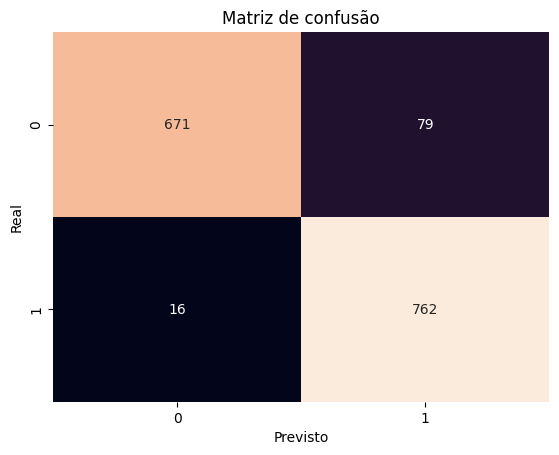

In [75]:
sns.heatmap(
    confusion_matrix(y_train, y_prev_4),
    cbar=False,
    annot=True,
    fmt='d'
)

plt.ylabel('Real')
plt.xlabel("Previsto")
plt.title('Matriz de confusão')

plt.show()

In [76]:
# =======================   
#   TESTE FINAL 
# =======================

y_prev_final = best_model.predict(X_test)
y_proba_final = best_model.predict_proba(X_test)[:,1]

print(f'Roc_Auc final: {roc_auc_score(y_test, y_proba_final):.2f}')
print(f'Relatório final: \n {classification_report(y_test, y_prev_final)}')

Roc_Auc final: 0.95
Relatório final: 
               precision    recall  f1-score   support

           0       0.91      0.88      0.90       258
           1       0.88      0.91      0.90       252

    accuracy                           0.90       510
   macro avg       0.90      0.90      0.90       510
weighted avg       0.90      0.90      0.90       510



In [77]:
# transformando relatório em dataframe
relatorio_final = classification_report(y_test, y_prev_final, output_dict=True)
relatorio_final = pd.DataFrame(relatorio_final)

# extraindo métricas
acuracia_final = relatorio_final.loc['precision', 'accuracy']
precisao_final = relatorio_final.loc['precision', '1']

# transformando em tabela
metricas_finais = {
    'modelo': ['Xgboost Classifier'],
    'roc_auc': [round(roc_auc_score(y_test, y_proba_final),2)],
    'acurácia': [round(acuracia_final,3)],
    'precisão': [round(precisao_final, 2)]
}

performance_final = pd.DataFrame(metricas_finais)

print(performance_final.to_markdown())

|    | modelo             |   roc_auc |   acurácia |   precisão |
|---:|:-------------------|----------:|-----------:|-----------:|
|  0 | Xgboost Classifier |      0.95 |      0.898 |       0.88 |


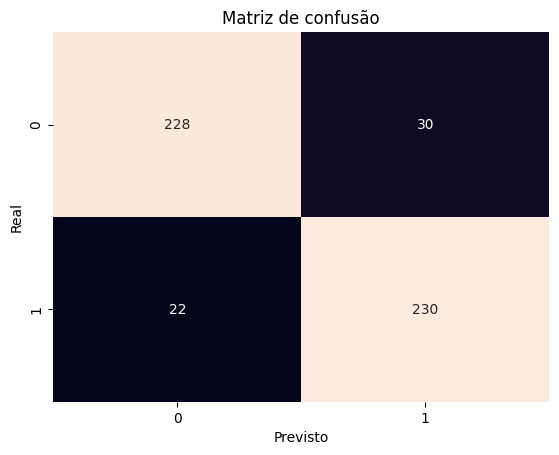

In [78]:
# matriz de confusão final
sns.heatmap(
    confusion_matrix(y_test, y_prev_final),
    cbar=False,
    annot=True,
    fmt='d'
)

plt.ylabel('Real')
plt.xlabel("Previsto")
plt.title('Matriz de confusão')

plt.show()

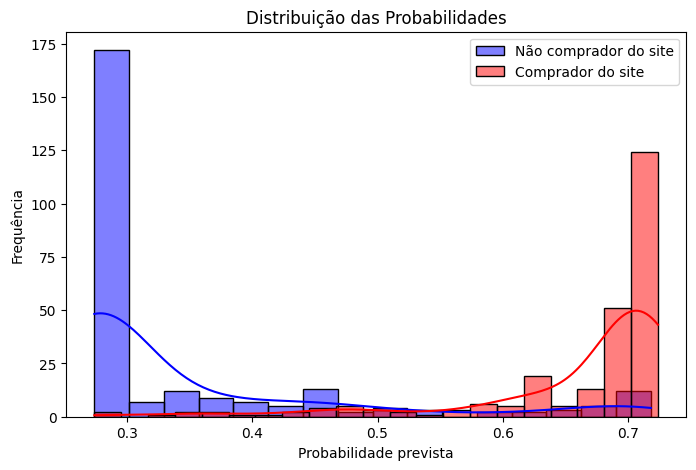

In [80]:
# separar por classe real
proba_0 = y_proba_final[y_test == 0]
proba_1 = y_proba_final[y_test == 1]

plt.figure(figsize=(8,5))

sns.histplot(proba_0, color='blue', label='Não comprador do site', kde=True)
sns.histplot(proba_1, color='red', label='Comprador do site', kde=True)

plt.xlabel('Probabilidade prevista')
plt.ylabel('Frequência')
plt.title('Distribuição das Probabilidades')
plt.legend()

plt.show()

,variaveis,importancia
21,gasto_total,0.41
24,score_M,0.20
3,total_vinhos,0.10
10,frequencia_site,0.06
5,total_carnes,0.05


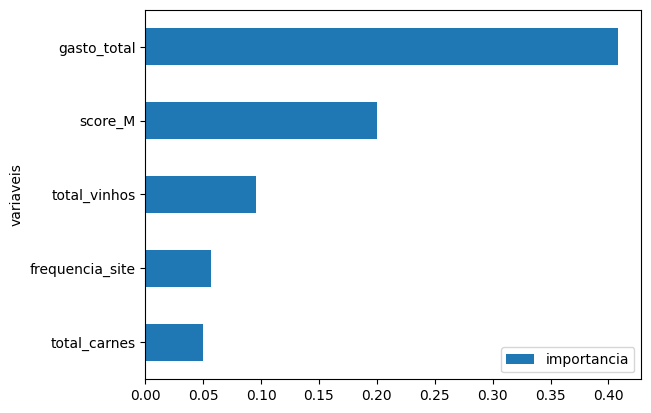

In [81]:
importancia = best_model.feature_importances_

features_importance = {
    'variaveis': X_train.columns,
    'importancia': importancia
}

df_importance = pd.DataFrame(features_importance)

display(df_importance.sort_values(by='importancia', ascending=False).head().round(2))

df_importance.nlargest(n=5,columns='importancia').plot(
    x= 'variaveis',
    y= 'importancia',
    kind='barh'
)

plt.gca().invert_yaxis()
plt.show()